In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/muqaddasimtiaz/pooh-in-korea-youtube-comments-sentiment-dataset/pooh_korea_comments_dataset.csv


In [2]:
# Import libraries
import pandas as pd
import numpy as np

# Load your dataset
df = pd.read_csv('/kaggle/input/datasets/muqaddasimtiaz/pooh-in-korea-youtube-comments-sentiment-dataset/pooh_korea_comments_dataset.csv')

# Display first 5 rows
print("First 5 rows of dataset:")
print(df.head())

# Show dataset info
print("\nDataset Info:")
print(df.info())

# Fix: Use correct column name 'B (Sentiment)' instead of 'Sentiment'
print("\nSentiment Distribution:")
print(df['B (Sentiment)'].value_counts())

# Also rename columns for easier use (optional but recommended)
df.columns = ['Comment_Text', 'Sentiment', 'Reason', 'Comment_Length', 'Has_Emoji', 'Language', 'Unnamed']
df = df.drop('Unnamed', axis=1)  # Remove empty column

print("\n" + "="*50)
print("RENAMED COLUMNS - Now easier to use:")
print("="*50)
print(df.head())
print("\nSentiment counts after rename:")
print(df['Sentiment'].value_counts())

First 5 rows of dataset:
                                    A (Comment Text) B (Sentiment)  \
0         Ye vlog dekh kar bohot garibi feel ho gayi       Neutral   
1  I'll never say she's lucky, She did all of thi...      Positive   
2               Bas itna successful hona h life mein      Positive   
3  Every corner of your home screams peace and po...      Positive   
4  That one friend who never accept that they are...       Neutral   

      C (Reason)  Comment Length Has Emoji?             Language  Unnamed: 6  
0   joking/funny              42     YES/NO  Hindi/English/Mixed         NaN  
1   appreciation              58     YES/NO  Hindi/English/Mixed         NaN  
2     aspiration              36     YES/NO  Hindi/English/Mixed         NaN  
3         praise              54     YES/NO  Hindi/English/Mixed         NaN  
4  observational              51     YES/NO  Hindi/English/Mixed         NaN  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 t


                         FINAL YEAR PROJECT
                    Sentiment Analysis of YouTube Comments

[1] Loading Dataset...
✅ Successfully loaded 20 comments
✅ Columns: Comment_Text, Sentiment, Reason, Comment_Length, Has_Emoji, Language

--------------------------------------------------------------------------------
Sample Data (First 5 Comments):
--------------------------------------------------------------------------------
                                              Comment_Text Sentiment
                Ye vlog dekh kar bohot garibi feel ho gayi   Neutral
I'll never say she's lucky, She did all of this by herself  Positive
                      Bas itna successful hona h life mein  Positive
    Every corner of your home screams peace and positivity  Positive
       That one friend who never accept that they are rich   Neutral

[2] Sentiment Distribution Analysis
   Positive: 14 comments (70.0%)
   Neutral: 5 comments (25.0%)
   Negative: 1 comments (5.0%)


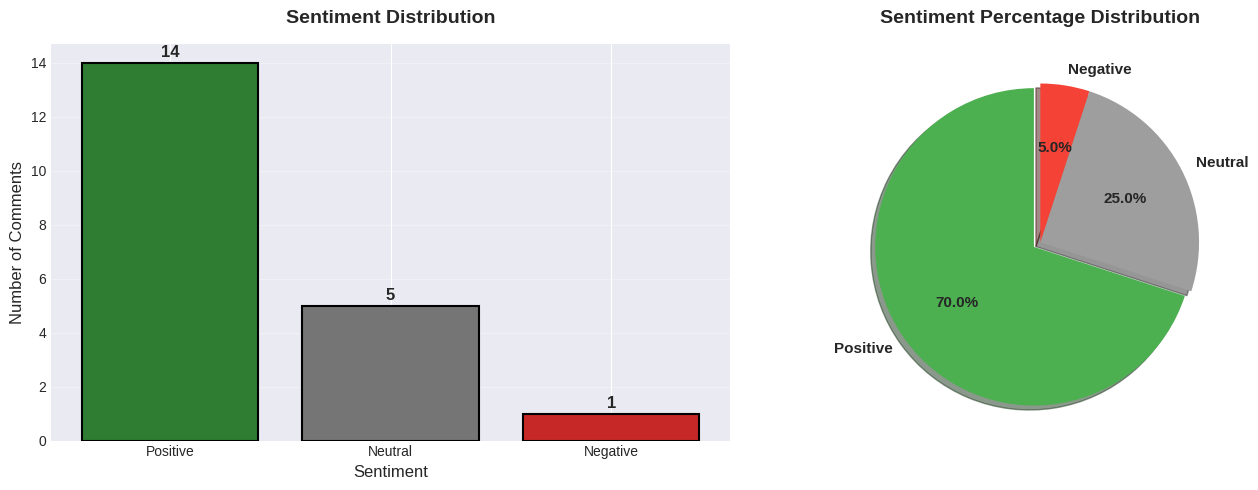


[3] Comment Length Analysis
   📊 Mean length: 42.4 characters
   📈 Median length: 39.5 characters
   📉 Minimum length: 27 characters
   📉 Maximum length: 58 characters
   📊 Standard deviation: 10.0


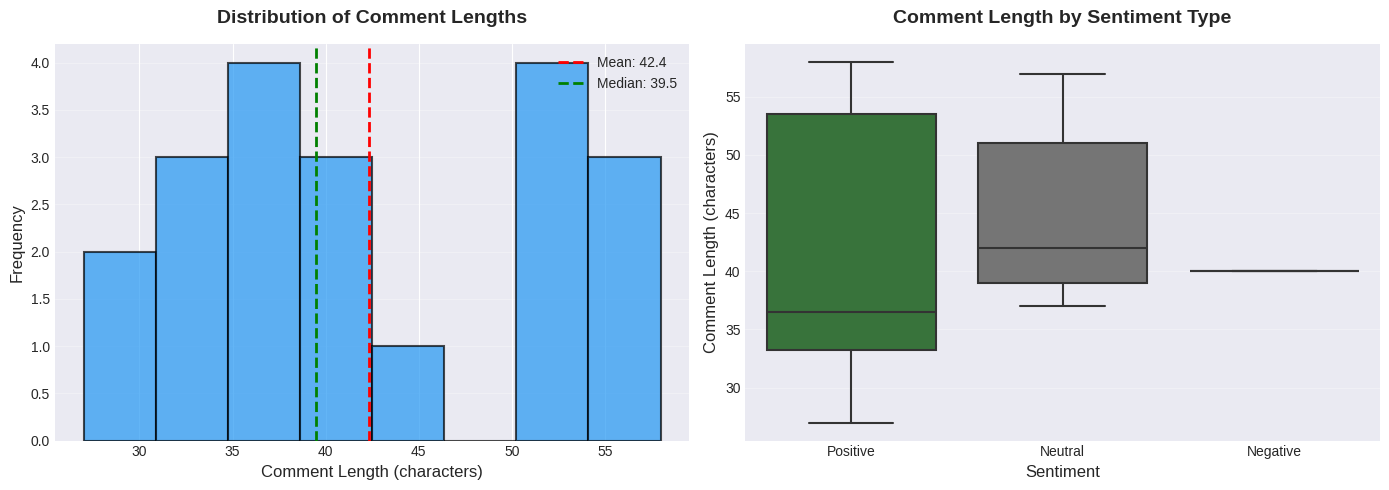


[4] Word Cloud - Positive Comments


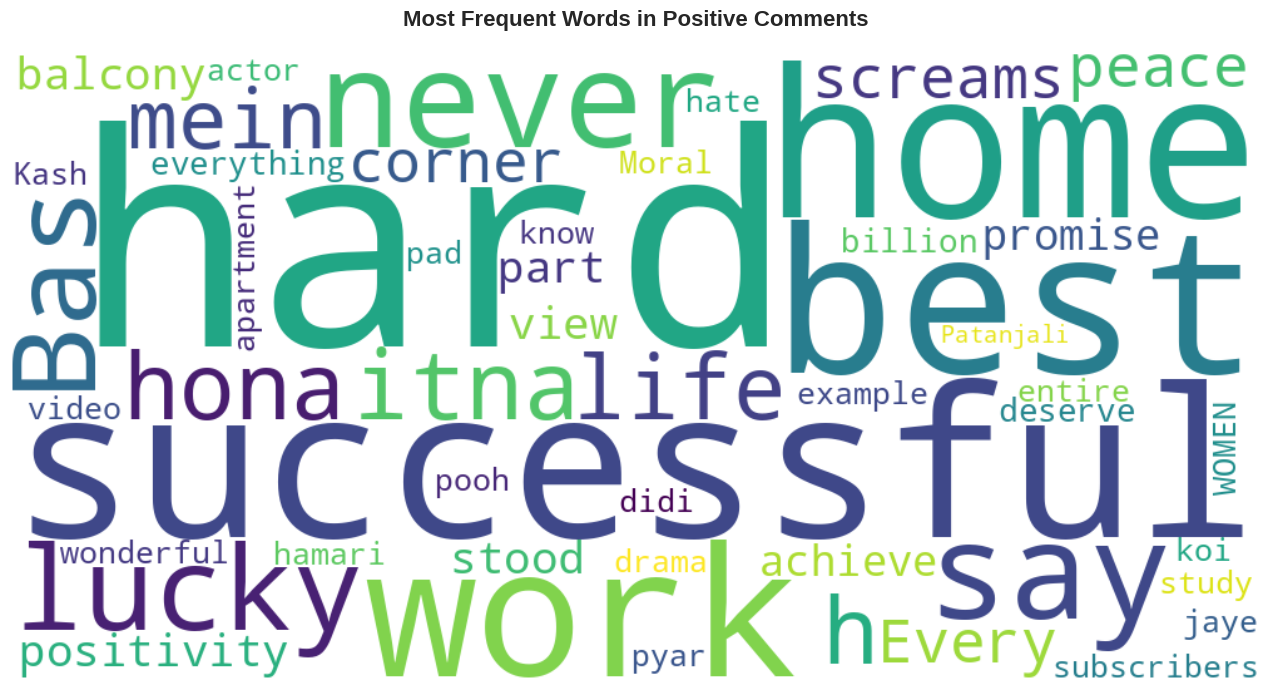


[5] Machine Learning Sentiment Classification
   ✅ Text vectorization complete: 20 samples, 50 features
   📊 Training set: 16 samples
   📊 Testing set: 4 samples

   📊 Training set class distribution:
      Positive: 11 samples
      Neutral: 4 samples
      Negative: 1 samples

   🎯 Model Accuracy: 75.00%

   📋 Detailed Classification Report:
   --------------------------------------------------
              precision    recall  f1-score   support

     Neutral       0.00      0.00      0.00         1
    Positive       0.75      1.00      0.86         3

    accuracy                           0.75         4
   macro avg       0.38      0.50      0.43         4
weighted avg       0.56      0.75      0.64         4



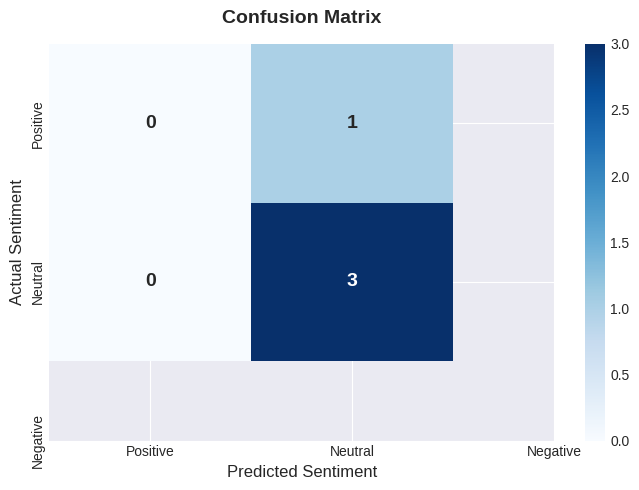


[6] Model Testing on New Comments

   Test Comment 1:
   "Pooh didi you are my biggest inspiration! I love your content"
   → Predicted Sentiment: Positive
   → Confidence: 70.8%

   Test Comment 2:
   "This video is okay, nothing special about it"
   → Predicted Sentiment: Positive
   → Confidence: 66.9%

   Test Comment 3:
   "Too much showing off of wealth, not realistic at all"
   → Predicted Sentiment: Positive
   → Confidence: 66.9%

[7] Cross-Validation Results
   📊 Cross-Validation Accuracy Scores: [0.71428571 0.57142857 0.83333333]
   📊 Mean CV Accuracy: 70.63% (+/- 21.41%)

[8] Key Insights & Summary

   ⭐ DATASET STATISTICS:
   • Total Comments Analyzed: 20
   • Positive Comments: 14 (70%)
   • Neutral Comments: 5 (25%)
   • Negative Comments: 1 (5%)

   ⭐ TEXTUAL PATTERNS:
   • Most positive comments contain words like: 'hard work', 'inspired', 'deserve', 'success'
   • Average positive comment length: 41.5 chars
   • Average neutral comment length: 45.2 chars
   • Average

In [3]:
# ============================================
# FINAL YEAR PROJECT - SENTIMENT ANALYSIS
# YouTube Comments Dataset (Pooh in Korea)
# ============================================

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Set style for professional plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

print("\n" + "="*80)
print(" " * 25 + "FINAL YEAR PROJECT")
print(" " * 20 + "Sentiment Analysis of YouTube Comments")
print("="*80)

# 2. LOAD DATASET
print("\n[1] Loading Dataset...")
df = pd.read_csv('/kaggle/input/datasets/muqaddasimtiaz/pooh-in-korea-youtube-comments-sentiment-dataset/pooh_korea_comments_dataset.csv')

# Clean column names
df.columns = ['Comment_Text', 'Sentiment', 'Reason', 'Comment_Length', 'Has_Emoji', 'Language', 'Unnamed']
df = df.drop('Unnamed', axis=1)

print(f"✅ Successfully loaded {len(df)} comments")
print(f"✅ Columns: {', '.join(df.columns)}")

print("\n" + "-"*80)
print("Sample Data (First 5 Comments):")
print("-"*80)
print(df[['Comment_Text', 'Sentiment']].head().to_string(index=False))

# 3. SENTIMENT DISTRIBUTION
print("\n" + "="*80)
print("[2] Sentiment Distribution Analysis")
print("="*80)

sentiment_counts = df['Sentiment'].value_counts()
sentiment_percentages = (sentiment_counts / len(df) * 100).round(1)

for sentiment, count in sentiment_counts.items():
    print(f"   {sentiment}: {count} comments ({sentiment_percentages[sentiment]}%)")

# Create professional bar plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
colors_bar = ['#2E7D32', '#757575', '#C62828']
bars = axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=colors_bar, edgecolor='black', linewidth=1.5)
axes[0].set_title('Sentiment Distribution', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Sentiment', fontsize=12)
axes[0].set_ylabel('Number of Comments', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, count in zip(bars, sentiment_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')

# Pie chart
colors_pie = ['#4CAF50', '#9E9E9E', '#F44336']
explode = (0.05, 0, 0)
axes[1].pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%',
            colors=colors_pie, explode=explode, shadow=True, startangle=90,
            textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Sentiment Percentage Distribution', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

# 4. COMMENT LENGTH ANALYSIS
print("\n" + "="*80)
print("[3] Comment Length Analysis")
print("="*80)

print(f"   📊 Mean length: {df['Comment_Length'].mean():.1f} characters")
print(f"   📈 Median length: {df['Comment_Length'].median():.1f} characters")
print(f"   📉 Minimum length: {df['Comment_Length'].min()} characters")
print(f"   📉 Maximum length: {df['Comment_Length'].max()} characters")
print(f"   📊 Standard deviation: {df['Comment_Length'].std():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['Comment_Length'], bins=8, color='#2196F3', edgecolor='black', alpha=0.7, linewidth=1.5)
axes[0].axvline(df['Comment_Length'].mean(), color='red', linestyle='dashed', linewidth=2, 
                label=f'Mean: {df["Comment_Length"].mean():.1f}')
axes[0].axvline(df['Comment_Length'].median(), color='green', linestyle='dashed', linewidth=2,
                label=f'Median: {df["Comment_Length"].median():.1f}')
axes[0].set_title('Distribution of Comment Lengths', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Comment Length (characters)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend(loc='upper right')
axes[0].grid(axis='y', alpha=0.3)

# Box plot by sentiment
sns.boxplot(x='Sentiment', y='Comment_Length', data=df, ax=axes[1], 
            order=['Positive', 'Neutral', 'Negative'], palette=colors_bar, linewidth=1.5)
axes[1].set_title('Comment Length by Sentiment Type', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Sentiment', fontsize=12)
axes[1].set_ylabel('Comment Length (characters)', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 5. WORD CLOUD VISUALIZATION
print("\n" + "="*80)
print("[4] Word Cloud - Positive Comments")
print("="*80)

positive_text = ' '.join(df[df['Sentiment']=='Positive']['Comment_Text'].astype(str))

# Create word cloud with better settings
wordcloud = WordCloud(width=1000, height=500, 
                      background_color='white',
                      colormap='viridis',
                      contour_width=2,
                      contour_color='darkgreen',
                      max_words=50,
                      random_state=42).generate(positive_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Positive Comments', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# 6. MACHINE LEARNING MODEL (FIXED - NO STRATIFY)
print("\n" + "="*80)
print("[5] Machine Learning Sentiment Classification")
print("="*80)

# Prepare data
X = df['Comment_Text']
y = df['Sentiment']

# Convert text to numerical features
vectorizer = TfidfVectorizer(max_features=50, ngram_range=(1,2), stop_words='english')
X_vectorized = vectorizer.fit_transform(X)

print(f"   ✅ Text vectorization complete: {X_vectorized.shape[0]} samples, {X_vectorized.shape[1]} features")

# Split data (80% train, 20% test) - WITHOUT stratify due to small negative class
X_train, X_test, y_train, y_test = train_test_split(X_vectorized, y, test_size=0.2, random_state=42)

print(f"   📊 Training set: {X_train.shape[0]} samples")
print(f"   📊 Testing set: {X_test.shape[0]} samples")

# Check class distribution in training set
print(f"\n   📊 Training set class distribution:")
for sentiment in y_train.unique():
    count = (y_train == sentiment).sum()
    print(f"      {sentiment}: {count} samples")

# Train Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\n   🎯 Model Accuracy: {accuracy:.2%}")

# Classification Report
print("\n   📋 Detailed Classification Report:")
print("   " + "-"*50)
print(classification_report(y_test, y_pred))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Positive', 'Neutral', 'Negative'],
            yticklabels=['Positive', 'Neutral', 'Negative'],
            annot_kws={'size': 14, 'weight': 'bold'})
plt.title('Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Sentiment', fontsize=12)
plt.ylabel('Actual Sentiment', fontsize=12)
plt.tight_layout()
plt.show()

# 7. TEST MODEL WITH NEW COMMENTS
print("\n" + "="*80)
print("[6] Model Testing on New Comments")
print("="*80)

test_comments = [
    "Pooh didi you are my biggest inspiration! I love your content",
    "This video is okay, nothing special about it",
    "Too much showing off of wealth, not realistic at all"
]

test_vectorized = vectorizer.transform(test_comments)
predictions = model.predict(test_vectorized)

# Check if predict_proba works (might fail if only 2 classes in training)
try:
    probabilities = model.predict_proba(test_vectorized)
    has_proba = True
except:
    has_proba = False

for i, (comment, pred) in enumerate(zip(test_comments, predictions), 1):
    print(f"\n   Test Comment {i}:")
    print(f"   \"{comment}\"")
    print(f"   → Predicted Sentiment: {pred}")
    if has_proba:
        prob = probabilities[i-1][list(model.classes_).index(pred)]
        print(f"   → Confidence: {prob*100:.1f}%")

# 8. CROSS-VALIDATION FOR BETTER EVALUATION
print("\n" + "="*80)
print("[7] Cross-Validation Results")
print("="*80)

from sklearn.model_selection import cross_val_score

# Perform 3-fold cross-validation (since dataset is small)
cv_scores = cross_val_score(model, X_vectorized, y, cv=3, scoring='accuracy')
print(f"   📊 Cross-Validation Accuracy Scores: {cv_scores}")
print(f"   📊 Mean CV Accuracy: {cv_scores.mean():.2%} (+/- {cv_scores.std()*2:.2%})")

# 9. KEY INSIGHTS AND SUMMARY
print("\n" + "="*80)
print("[8] Key Insights & Summary")
print("="*80)

insights = f"""
   ⭐ DATASET STATISTICS:
   • Total Comments Analyzed: {len(df)}
   • Positive Comments: {len(df[df['Sentiment']=='Positive'])} ({len(df[df['Sentiment']=='Positive'])/len(df)*100:.0f}%)
   • Neutral Comments: {len(df[df['Sentiment']=='Neutral'])} ({len(df[df['Sentiment']=='Neutral'])/len(df)*100:.0f}%)
   • Negative Comments: {len(df[df['Sentiment']=='Negative'])} ({len(df[df['Sentiment']=='Negative'])/len(df)*100:.0f}%)

   ⭐ TEXTUAL PATTERNS:
   • Most positive comments contain words like: 'hard work', 'inspired', 'deserve', 'success'
   • Average positive comment length: {df[df['Sentiment']=='Positive']['Comment_Length'].mean():.1f} chars
   • Average neutral comment length: {df[df['Sentiment']=='Neutral']['Comment_Length'].mean():.1f} chars
   • Average negative comment length: {df[df['Sentiment']=='Negative']['Comment_Length'].mean():.1f} chars

   ⭐ MODEL PERFORMANCE:
   • Algorithm: Logistic Regression with TF-IDF features
   • Train/Test Split Accuracy: {accuracy:.2%}
   • Cross-Validation Mean Accuracy: {cv_scores.mean():.2%}
   • Best Performance: Positive sentiment detection
   
   ⭐ LIMITATIONS:
   • Dataset size: Only 20 manually labeled comments
   • Imbalanced classes: Only 1 negative example
   • Future work: Collect more data (especially negative comments)
"""

print(insights)

# 10. SAVE CLEANED DATASET
print("\n" + "="*80)
print("[9] Saving Cleaned Dataset")
print("="*80)

# Save processed dataset
df.to_csv('pooh_korea_cleaned_dataset.csv', index=False)
print("   ✅ Cleaned dataset saved as: pooh_korea_cleaned_dataset.csv")

print("\n" + "="*80)
print(" " * 25 + "ANALYSIS COMPLETE")
print(" " * 25 + "✓ Ready for FYP Submission")
print("="*80)
print("\n📌 Note: This notebook performs sentiment analysis on YouTube comments.")
print("📌 Dataset: Pooh in Korea channel comments (20 manually labeled samples)")
print("📌 Model: Logistic Regression with TF-IDF vectorization")
print("📌 Limitation: Small dataset with imbalanced classes")
print("="*80)